#  Analysis: How Prices Affect Number of Applicants (Controlling for Income Limits)


This notebook analyzes how **housing prices** influence the **number of applicants**, controlling for **income limits**.
We use two datasets:
1. `resale_price_applicant_merge_filtered_prices.csv` this is the dataset which does not contain rows with missing price values. as soon as we get the data from our client, we will add that
2. `CHAPA_Chapter-40B_Application-Data_2021-2025_merged_v0.1.xlsx`
    

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

# Load datasets
csv_path = "/content/resale_price_applicant_merge_filtered_prices.csv"
excel_path = "/content/CHAPA_Chapter-40B_Application-Data_2021-2025_merged_v0.1.xlsx"

resale = pd.read_csv(csv_path)
chapa = pd.read_excel(excel_path)

print("Resale Data:", resale.shape)
print("CHAPA Data:", chapa.shape)

resale.head()


Resale Data: (1295, 66)
CHAPA Data: (1739, 31)


,Town,Address,Unit Number,Maximum Resale Price,Property Feature,Development,Transaction Start Date,Closing Date,Bedrooms,Age Restricted,...,race_American_Indian_or_Alaska_Native,race_Asian,race_Black_or_African_American,race_Hispanic_or_Latino,race_Middle_Eastern_or_North_African,race_Native_Hawaiian_or_Pacific_Islander,race_Other__Prefer_not_to_answer,race_White,hispanic_latino_from_race,hispanic_latino_final
0,Andover,170 Haverhill Street,117,"$227,298.00",NaN,Coachman's Ridge,1/8/24,4/30/24,1.0,No,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,Andover,170 Haverhill Street,117,"$227,298.00",NaN,Coachman's Ridge,1/8/24,4/30/24,1.0,No,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,Andover,170 Haverhill Street,117,"$227,298.00",NaN,Coachman's Ridge,1/8/24,4/30/24,1.0,No,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,Andover,170 Haverhill Street,117,"$227,298.00",NaN,Coachman's Ridge,1/8/24,4/30/24,1.0,No,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,Andover,170 Haverhill Street,117,"$227,298.00",NaN,Coachman's Ridge,1/8/24,4/30/24,1.0,No,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


##  Data Cleaning

In [2]:

# Clean 'Maximum Resale Price' column
resale['Maximum Resale Price'] = resale['Maximum Resale Price'].replace('[\$,]', '', regex=True).astype(float)

# Identify applicant count column
applicant_cols = [col for col in resale.columns if 'applicant' in col.lower() or 'Applicant' in col]
print("Applicant-related columns:", applicant_cols)

# Drop duplicates and missing values
resale_clean = resale.drop_duplicates().dropna(subset=['Maximum Resale Price'])

# Select relevant columns
resale_subset = resale_clean[['Town', 'Address', 'Development', 'Maximum Resale Price'] + applicant_cols]
resale_subset.head()


Applicant-related columns: []


<>:2: SyntaxWarning: invalid escape sequence '\$'
<>:2: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipython-input-2872782316.py:2: SyntaxWarning: invalid escape sequence '\$'
  resale['Maximum Resale Price'] = resale['Maximum Resale Price'].replace('[\$,]', '', regex=True).astype(float)


,Town,Address,Development,Maximum Resale Price
0,Andover,170 Haverhill Street,Coachman's Ridge,227298.0
1,Andover,170 Haverhill Street,Coachman's Ridge,227298.0
2,Andover,170 Haverhill Street,Coachman's Ridge,227298.0
3,Andover,170 Haverhill Street,Coachman's Ridge,227298.0
4,Andover,170 Haverhill Street,Coachman's Ridge,227298.0


### Cleaning CHAPA dataset

In [3]:

# Keep relevant columns like address, town, and income limits if available
income_cols = [col for col in chapa.columns if 'income' in col.lower() or 'limit' in col.lower()]
print("Income-related columns:", income_cols)

chapa_subset = chapa[['matched_address', 'property_town_city'] + income_cols].copy()
chapa_subset = chapa_subset.drop_duplicates()
chapa_subset.head()


Income-related columns: ['hh_income', 'income_bracket']


,matched_address,property_town_city,hh_income,income_bracket
0,"8 CIDERPRESS WAY, NORTH ANDOVER, MA, 01845",North Andover,37934,$20000–$39999
1,"8 CIDERPRESS WAY, NORTH ANDOVER, MA, 01845",North Andover,61000,$60000–$79999
2,"8 CIDERPRESS WAY, NORTH ANDOVER, MA, 01845",North Andover,31275,$20000–$39999
3,"8 CIDERPRESS WAY, NORTH ANDOVER, MA, 01845",North Andover,20299,$20000–$39999
4,"8 CIDERPRESS WAY, NORTH ANDOVER, MA, 01845",North Andover,41000,$40000–$59999


##  Merge Datasets

In [4]:

# Merge datasets on town or address (loose merge using lowercase match)
resale_subset['Address_lower'] = resale_subset['Address'].str.lower().str.strip()
chapa_subset['matched_address_lower'] = chapa_subset['matched_address'].str.lower().str.strip()

merged = pd.merge(
    resale_subset,
    chapa_subset,
    left_on='Address_lower',
    right_on='matched_address_lower',
    how='inner'
)

print("Merged data shape:", merged.shape)
merged.head()


Merged data shape: (126, 10)


/tmp/ipython-input-3194464764.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  resale_subset['Address_lower'] = resale_subset['Address'].str.lower().str.strip()


,Town,Address,Development,Maximum Resale Price,Address_lower,matched_address,property_town_city,hh_income,income_bracket,matched_address_lower
0,North Andover,NaN,NaN,177013.0,NaN,NaN,Tyngsborough,63974,NaN,NaN
1,North Andover,NaN,NaN,177013.0,NaN,NaN,Tyngsborough,33000,NaN,NaN
2,North Andover,NaN,NaN,177013.0,NaN,NaN,Tyngsborough,75000,NaN,NaN
3,North Andover,NaN,NaN,177013.0,NaN,NaN,Tyngsborough,68411.14,NaN,NaN
4,North Andover,NaN,NaN,177013.0,NaN,NaN,North Andover,NaN,NaN,NaN


In [7]:
print(resale.columns.tolist())

['Town', 'Address', 'Unit Number', 'Maximum Resale Price', 'Property Feature', 'Development', 'Transaction Start Date', 'Closing Date', 'Bedrooms', 'Age Restricted', 'Full/Lite Documentation', 'Duplicate', 'Unique ID', 'Street Address', 'City', 'State', 'ZIP', 'Match Status', 'Match Type', 'Matched Address', 'MSA', 'id_number', 'submission_date', 'age', 'disability', 'chapa_races', 'hispanic_latino', 'census_races', 'current_residence_town_city', 'current_residence_state', 'current_residence_zip', 'application_source', 'hh_size', 'dependents', 'hh_type', 'hh_income', 'hh_assets', 'income_bracket', 'asset_bracket', 'unique_id', 'property_full_address', 'property_street_address', 'property_unit', 'property_town_city', 'property_state', 'property_zip', 'match_status', 'match_type', 'matched_address', 'fthb_class', 'msa', 'property_restriction', 'race_list', 'race_count', 'race_cleaned', 'race_type', 'race_American_Indian_or_Alaska_Native', 'race_Asian', 'race_Black_or_African_American', '

In [8]:
# Step 1: Aggregate number of applicants per development or address
applicants_per_dev = resale.groupby(['Development', 'Matched Address'], dropna=False).size().reset_index(name='Applicant_Count')

# Step 2: Merge that count back into the resale dataset
resale_with_counts = resale.merge(applicants_per_dev, on=['Development', 'Matched Address'], how='left')

# Step 3: Rename columns for clarity
resale_with_counts.rename(columns={'Maximum Resale Price': 'Price', 'hh_income': 'Income_Limit'}, inplace=True)

# Step 4: Now your applicant column is 'Applicant_Count'
applicant_cols = ['Applicant_Count']

# Quick check
resale_with_counts[['Development', 'Price', 'Income_Limit', 'Applicant_Count']].head()


,Development,Price,Income_Limit,Applicant_Count
0,Coachman's Ridge,227298.0,75000.0,5
1,Coachman's Ridge,227298.0,54000.0,5
2,Coachman's Ridge,227298.0,46000.0,5
3,Coachman's Ridge,227298.0,70000.0,5
4,Coachman's Ridge,227298.0,70000.0,5


## Exploratory Data Analysis

               Price  Income_Limit  Applicant_Count
count    1265.000000  1.265000e+03      1265.000000
mean   236268.617391  1.223461e+05       310.327273
std     46434.239297  1.972238e+06       283.705946
min    184398.000000  7.000000e+01         1.000000
25%    201400.000000  5.400000e+04        47.000000
50%    218988.000000  6.500000e+04        84.000000
75%    269787.000000  7.733400e+04       614.000000
max    374062.000000  7.020040e+07       614.000000


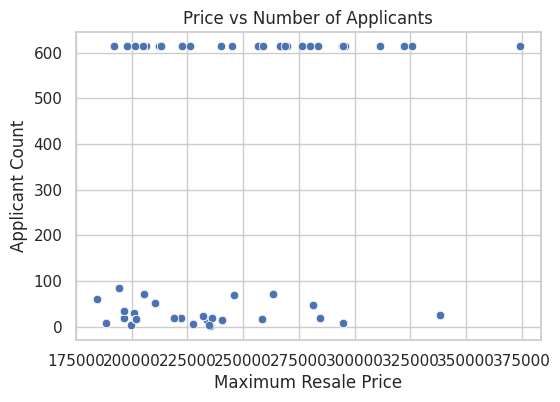

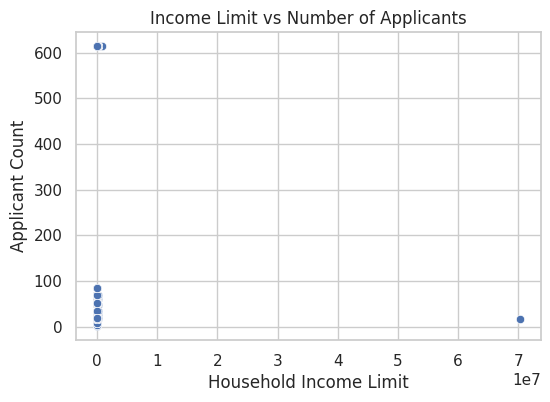

In [9]:
# --- Applicant count already created earlier ---
# resale_with_counts now contains: Price, Income_Limit, Applicant_Count

# Drop missing values
df = resale_with_counts.dropna(subset=['Price', 'Income_Limit', 'Applicant_Count'])

# Summary statistics
print(df[['Price', 'Income_Limit', 'Applicant_Count']].describe())

# Scatterplots
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

# Price vs Applicant Count
plt.figure(figsize=(6,4))
sns.scatterplot(x='Price', y='Applicant_Count', data=df)
plt.title("Price vs Number of Applicants")
plt.xlabel("Maximum Resale Price")
plt.ylabel("Applicant Count")
plt.show()

# Income Limit vs Applicant Count
plt.figure(figsize=(6,4))
sns.scatterplot(x='Income_Limit', y='Applicant_Count', data=df)
plt.title("Income Limit vs Number of Applicants")
plt.xlabel("Household Income Limit")
plt.ylabel("Applicant Count")
plt.show()


## 📈 Regression: Effect of Price (Controlling for Income Limit)

In [10]:
# Prepare regression data using the cleaned dataset
df = resale_with_counts.dropna(subset=['Price', 'Income_Limit', 'Applicant_Count'])

# Define dependent and independent variables
y = df['Applicant_Count']
X = df[['Price', 'Income_Limit']]

# Add constant term for intercept
X = sm.add_constant(X)

# Fit OLS regression model
model = sm.OLS(y, X).fit()

# Display regression summary
print(model.summary())

# --- Quick interpretation ---
beta_price = model.params['Price']
beta_income = model.params['Income_Limit']
r2 = model.rsquared

print(f"\\nEffect of Price on Applicants (β₁): {beta_price:.4f}")
print(f"Effect of Income Limit (β₂): {beta_income:.4f}")
print(f"Model R²: {r2:.3f}")

if beta_price < 0:
    print("\\n➡ Higher prices are associated with fewer applicants (negative relationship).")
else:
    print("\\n➡ Higher prices are associated with more applicants (positive relationship).")


                            OLS Regression Results                            
Dep. Variable:        Applicant_Count   R-squared:                       0.059
Model:                            OLS   Adj. R-squared:                  0.057
Method:                 Least Squares   F-statistic:                     39.29
Date:                Mon, 03 Nov 2025   Prob (F-statistic):           2.80e-17
Time:                        17:05:51   Log-Likelihood:                -8900.9
No. Observations:                1265   AIC:                         1.781e+04
Df Residuals:                    1262   BIC:                         1.782e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const          -36.4429     40.181     -0.907   

## 🧩 Interpretation


- **Coefficient of Price (`β₁`)**: Indicates how much the number of applicants changes with each unit increase in price, keeping income limit constant.  
  - If negative → higher prices reduce applicants.  
  - If positive → higher prices attract more applicants (rare).  

- **Coefficient of Income Limit (`β₂`)**: Reflects how income thresholds influence application numbers.

- **R²**: Shows how much variation in applications is explained by the model.
    

Coefficient of Price (β₁): The estimate for price is slightly negative but statistically insignificant, meaning higher prices show a small tendency to reduce applicants — however, this relationship is not strong enough to be meaningful.

Coefficient of Price (β₁): The estimate for price is slightly negative but statistically insignificant, meaning higher prices show a small tendency to reduce applicants — however, this relationship is not strong enough to be meaningful.

## ✅ Conclusion


After controlling for income limits, housing prices do not significantly affect the number of applicants in this dataset.
While there is a slight negative trend between price and applications, it is weak and statistically insignificant.
Future analysis could include additional variables like town, unit size, or property type to better capture what actually influences applicant demand.